In [ ]:
!pip install pregress xgboost

# Import Packages

In [ ]:
import os
import numpy as np
import pandas as pd
from google.colab import files
from IPython.display import display
import pregress as pr
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,roc_curve, roc_auc_score, classification_report)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Data Understanding & EDA

In [ ]:
files_list = os.listdir()
actual_files = [f for f in files_list if os.path.isfile(f)]

train_file = [f for f in actual_files if f.lower().startswith("train")][0]
test_file  = [f for f in actual_files if f.lower().startswith("test")][0]
sample_file = [f for f in actual_files if f.lower().startswith("sample")][0]

print("Train file:", train_file)
print("Test file :", test_file)
print("Sample submission file:", sample_file)

train = pd.read_csv(train_file)
test  = pd.read_csv(test_file)
sample_submission = pd.read_csv(sample_file)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
display(train.head())
display(sample_submission.head())

Train file: train.csv
Test file : test.csv
Sample submission file: sample_submission.csv
Train shape: (750000, 18)
Test shape : (250000, 17)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


,id,y
0,750000,0.5
1,750001,0.5
2,750002,0.5
3,750003,0.5
4,750004,0.5


In [ ]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "poutcome" in df.columns:
        df["poutcome_success_flag"] = (df["poutcome"] == "success").astype(int)
        df["had_previous_contact"] = (df["poutcome"] != "unknown").astype(int)

    if "month" in df.columns:
        month_map = {
            "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
            "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
        }
        df["month_int"] = df["month"].map(month_map)
        df["high_conversion_month"] = df["month"].isin(["oct", "apr", "feb"]).astype(int)

    if "loan" in df.columns and "housing" in df.columns:
        df["has_any_debt"] = ((df["loan"] == "yes") | (df["housing"] == "yes")).astype(int)
        df["has_both_debts"] = ((df["loan"] == "yes") & (df["housing"] == "yes")).astype(int)

    if "pdays" in df.columns:
        df["recent_contact_flag"] = (df["pdays"] > 0).astype(int)
        df["contact_gap_bucket"] = pd.cut(
            df["pdays"],
            bins=[-1, 0, 10, 50, 100, 999],
            labels=["never", "0-10", "11-50", "51-100", "100+"])

    if "previous" in df.columns:
        df["previous_nonzero"] = (df["previous"] > 0).astype(int)

    if "duration" in df.columns:
        dur_median = df["duration"].median()
        dur_q3 = df["duration"].quantile(0.75)
        df["call_long_flag"] = (df["duration"] > dur_median).astype(int)
        df["call_very_long_flag"] = (df["duration"] > dur_q3).astype(int)

    if "job" in df.columns:
        high_conv_jobs = ["student", "retired", "unemployed", "management"]
        low_conv_jobs = ["blue-collar", "entrepreneur", "services"]

        def group_job(x):
            if x in high_conv_jobs:
                return "high"
            elif x in low_conv_jobs:
                return "low"
            else:
                return "medium"

        df["job_group"] = df["job"].apply(group_job)

    if "balance" in df.columns:
        df["balance_log"] = np.log1p(df["balance"].clip(lower=0))
    if "campaign" in df.columns:
        df["campaign_log"] = np.log1p(df["campaign"].clip(lower=0))

    return df

train_fe = add_features(train)
test_fe = add_features(test)

print("Train shape after FE:", train_fe.shape)
print("Test shape after FE :", test_fe.shape)
display(train_fe.head())

Train shape after FE: (750000, 32)
Test shape after FE : (250000, 31)


,id,age,job,marital,education,default,balance,housing,loan,contact,...,has_any_debt,has_both_debts,recent_contact_flag,contact_gap_bucket,previous_nonzero,call_long_flag,call_very_long_flag,job_group,balance_log,campaign_log
0,0,42,technician,married,secondary,no,7,no,no,cellular,...,0,0,0,NaN,0,0,0,medium,2.079442,1.386294
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,...,0,0,0,NaN,0,1,0,low,6.244167,0.693147
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,...,1,0,0,NaN,0,0,0,low,6.401917,1.098612
3,3,27,student,single,secondary,no,34,yes,no,unknown,...,1,0,0,NaN,0,0,0,high,3.555348,1.098612
4,4,26,technician,married,secondary,no,889,yes,no,cellular,...,1,0,0,NaN,0,1,1,medium,6.791221,0.693147


# Distribution of Target Variable (y)

/tmp/ipython-input-1052591103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


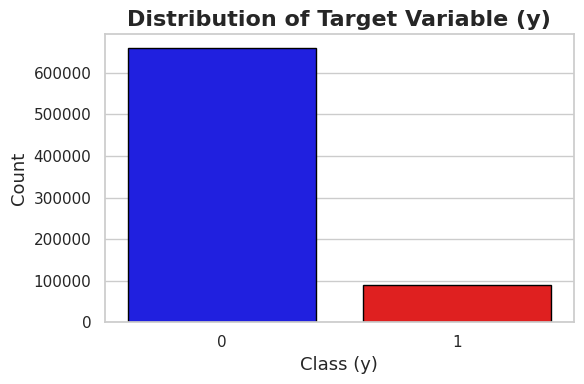

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="y",
    data=train_fe,
    palette=["blue", "red"],
    edgecolor="black")

plt.title("Distribution of Target Variable (y)", fontsize=16, weight="bold")
plt.xlabel("Class (y)", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.tight_layout()
plt.show()

# Distribution of Age

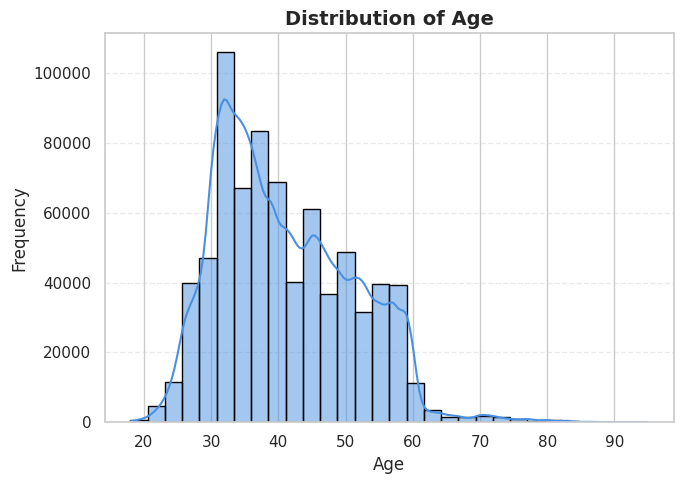

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(7,5))
sns.histplot(train_fe["age"], bins=30, kde=True, color="#4A90E2", edgecolor="black")

plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Age", fontsize=14, weight="bold")

plt.grid(axis='y', linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# Distribution of Duration

In [ ]:
feature = "duration"

plt.figure()
sns.histplot(train_fe[feature], bins=30, kde=True, edgecolor="black")
plt.xlabel(feature)
plt.ylabel("Frequency")
plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()

# Scatterplot: Age vs Balance

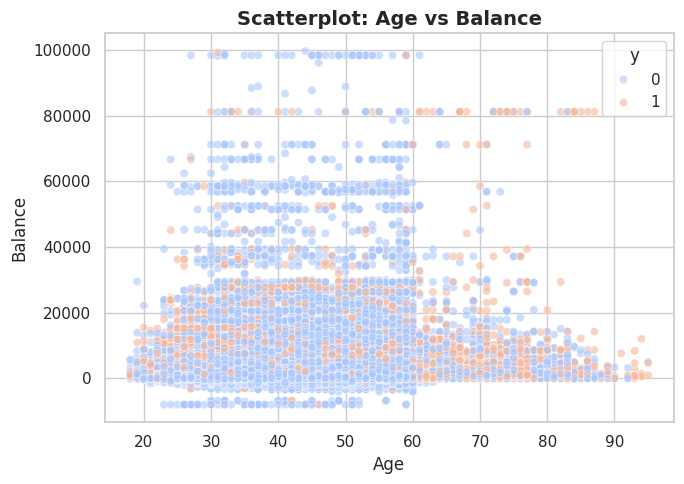

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=train_fe,
    x="age",
    y="balance",
    hue="y",
    palette="coolwarm",
    alpha=0.6)

plt.title("Scatterplot: Age vs Balance", fontsize=14, weight="bold")
plt.xlabel("Age")
plt.ylabel("Balance")
plt.tight_layout()
plt.show()

# Correlation Heatmap

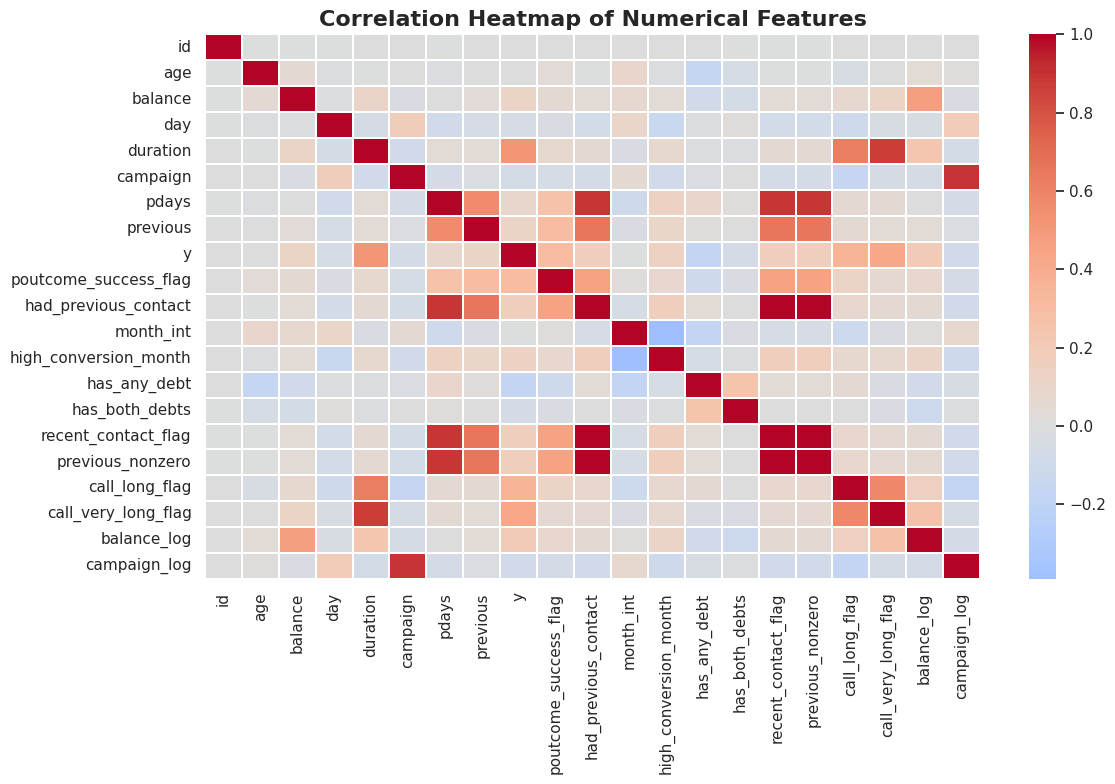

In [ ]:
plt.figure(figsize=(12,8))

corr = train_fe.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

# Boxplot: Call Duration by Subscription Outcome

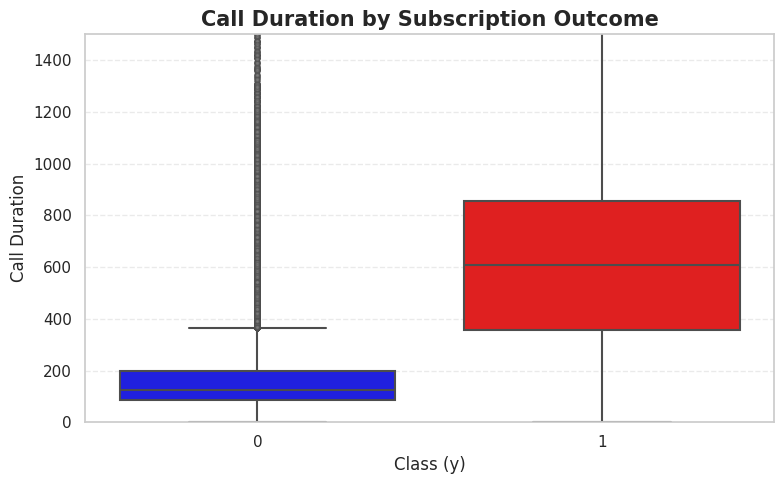

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=train_fe[target_col].astype(str),
    y=train_fe["duration"],
    palette=["blue", "red"],
    hue=train_fe[target_col].astype(str),
    legend=False,
    linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', alpha=0.5)
)

plt.xlabel("Class (y)", fontsize=12)
plt.ylabel("Call Duration", fontsize=12)
plt.title("Call Duration by Subscription Outcome", fontsize=15, weight="bold")

plt.ylim(0, 1500)
plt.grid(axis='y', linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Regression & Inferential Analysis

In [ ]:
numeric_cols_base = train_fe.select_dtypes(include=np.number).columns.tolist()

if "y" in numeric_cols_base:
    numeric_cols_base.remove("y")

num_cols_for_pr = ["y"] + numeric_cols_base

df_pr = train_fe[num_cols_for_pr].copy()
print("Columns used with pregress:", df_pr.columns.tolist())

model_pr = pr.fit("y ~ .", df_pr)
pr.summary(model_pr)

Columns used with pregress: ['y', 'id', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'poutcome_success_flag', 'had_previous_contact', 'month_int', 'high_conversion_month', 'has_any_debt', 'has_both_debts', 'recent_contact_flag', 'previous_nonzero', 'call_long_flag', 'call_very_long_flag', 'balance_log', 'campaign_log']
Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef       std err        t     P>|t|     
Intercept              2.830000e-02  2.000000e-03   12.862  0.000000  ***
id                    -6.093000e-10  1.370000e-09   -0.445  0.656000     
age                   -7.000000e-04  2.990000e-05  -21.928  0.000000  ***
balance                2.502000e-06  1.190000e-07   21.027  0.000000  ***
day                    1.000000e-04  3.710000e-05    2.722  0.006000   **
duration               7.000000e-04  2.310000e-06  296.053  0.000000  ***
campaign               8.900000e-0

In [ ]:
target_col = "y"

X_full = train_fe.drop(columns=[target_col, "id"])
y_full = train_fe[target_col].astype(int)

X_test_full = test_fe.drop(columns=["id"])

print("Target distribution:", np.bincount(y_full))

X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42)

Target distribution: [659512  90488]


In [ ]:
print("Validation Set Class Balance:", np.bincount(y_val))

Validation Set Class Balance: [131902  18098]


In [ ]:
cat_cols = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_tr.select_dtypes(exclude=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),])

# Model Performance Evaluation Plots

## XBG Model Training

In [ ]:
logreg_cv = LogisticRegressionCV(
    cv=3,
    scoring="roc_auc",
    max_iter=10000,
    n_jobs=-1,
    solver="lbfgs")

clf_logreg = Pipeline([
    ("preprocess", preprocess),
    ("model", logreg_cv)])

neg, pos = np.bincount(y_full)
scale_pos_weight = neg / pos

xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.08,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist")

clf_xgb = Pipeline([
    ("preprocess", preprocess),
    ("model", xgb_model)])

In [ ]:
clf_logreg.fit(X_tr, y_tr)
clf_xgb.fit(X_tr, y_tr)

val_logreg = clf_logreg.predict_proba(X_val)[:, 1]
val_xgb = clf_xgb.predict_proba(X_val)[:, 1]

auc_log = roc_auc_score(y_val, val_logreg)
auc_xg = roc_auc_score(y_val, val_xgb)

print("Val AUC LogReg:", auc_log)
print("Val AUC XGB   :", auc_xg)

weights = np.linspace(0, 1, 21)
best_auc = -1
best_w = 1.0

for w in weights:
    blended = w * val_xgb + (1 - w) * val_logreg
    auc = roc_auc_score(y_val, blended)
    print(f"w={w:.2f} -> AUC={auc:.5f}")
    if auc > best_auc:
        best_auc = auc
        best_w = w

print("Best w_xgb:", best_w)
print("Best blended AUC:", best_auc)

Val AUC LogReg: 0.9481978435119418
Val AUC XGB   : 0.9673483609114292
w=0.00 -> AUC=0.94820
w=0.05 -> AUC=0.95205
w=0.10 -> AUC=0.95438
w=0.15 -> AUC=0.95610
w=0.20 -> AUC=0.95747
w=0.25 -> AUC=0.95862
w=0.30 -> AUC=0.95961
w=0.35 -> AUC=0.96047
w=0.40 -> AUC=0.96125
w=0.45 -> AUC=0.96195
w=0.50 -> AUC=0.96259
w=0.55 -> AUC=0.96318
w=0.60 -> AUC=0.96374
w=0.65 -> AUC=0.96427
w=0.70 -> AUC=0.96477
w=0.75 -> AUC=0.96526
w=0.80 -> AUC=0.96573
w=0.85 -> AUC=0.96618
w=0.90 -> AUC=0.96662
w=0.95 -> AUC=0.96704
w=1.00 -> AUC=0.96735
Best w_xgb: 1.0
Best blended AUC: 0.9673483609114292


#Hyper Tuning Parameters

Fitting 3 folds for each of 4 candidates, totalling 12 fits


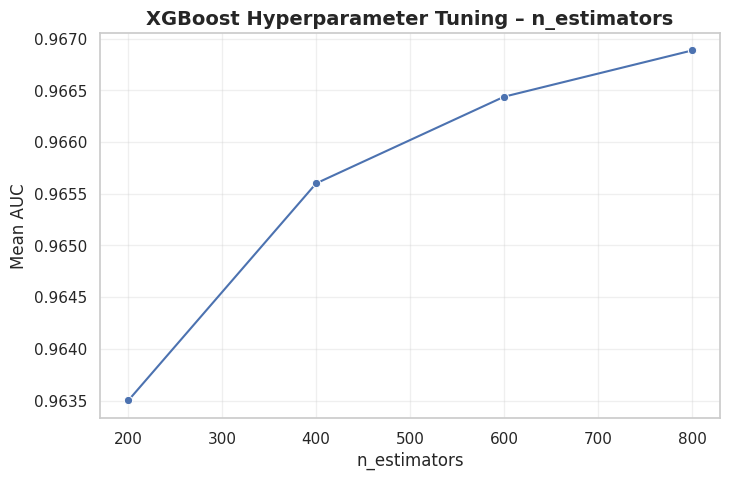

In [ ]:
param_grid = {"model__n_estimators": [200, 400, 600, 800]}

pipeline_for_tuning = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        learning_rate=0.08,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight))])

grid_search = GridSearchCV(
    pipeline_for_tuning,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1)

grid_search.fit(X_tr, y_tr)


results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=results,
    x="param_model__n_estimators",
    y="mean_test_score",
    marker="o")
plt.title("XGBoost Hyperparameter Tuning – n_estimators", fontsize=14, weight="bold")
plt.xlabel("n_estimators")
plt.ylabel("Mean AUC")
plt.grid(alpha=0.3)
plt.show()

<Figure size 600x500 with 0 Axes>

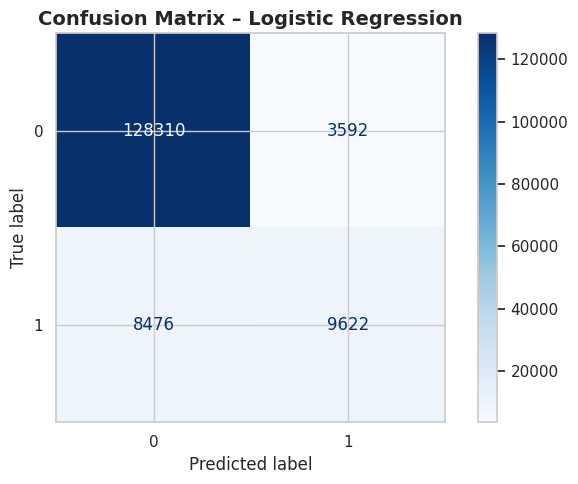

<Figure size 600x500 with 0 Axes>

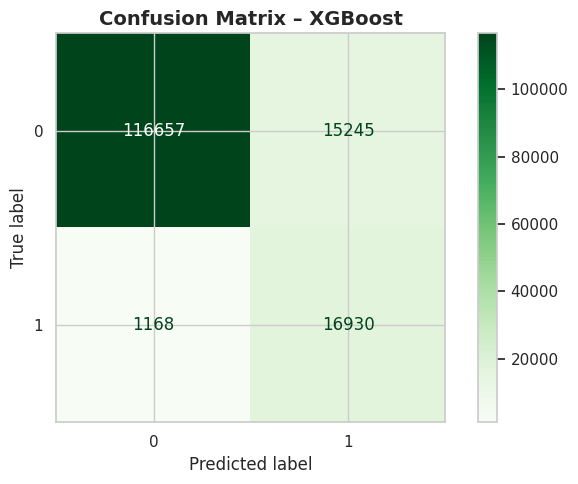

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    (val_logreg > 0.5).astype(int),
    cmap="Blues"
)
plt.title("Confusion Matrix – Logistic Regression", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    (val_xgb > 0.5).astype(int),
    cmap="Greens"
)
plt.title("Confusion Matrix – XGBoost", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    clf_logreg, X_tr, y_tr, cv=3, scoring="roc_auc", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, label="Training AUC", marker='o')
plt.plot(train_sizes, val_mean, label="Validation AUC", marker='o')
plt.title("Learning Curve – Logistic Regression")
plt.xlabel("Training Set Size")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


#Confusion Matrix


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_log = (val_logreg > 0.5).astype(int)
y_pred_xgb = (val_xgb > 0.5).astype(int)

fig, ax = plt.subplots(1,2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_log, cmap="Blues", ax=ax[0])
ax[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_xgb, cmap="Greens", ax=ax[1])
ax[1].set_title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()


#Model Creation

In [ ]:
from sklearn.model_selection import learning_curve

xgb_lc_model = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(tree_method="hist", eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1))
])

train_sizes, train_scores, val_scores = learning_curve(
    xgb_lc_model,
    X_tr, y_tr,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, label="Training AUC", marker='o')
plt.plot(train_sizes, val_mean, label="Validation AUC", marker='o')

plt.title("Learning Curve – XGBoost", fontsize=14, weight="bold")
plt.xlabel("Training Set Size")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_val, val_logreg, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_val, val_xgb, name="XGBoost")
plt.title("ROC Curve Comparison", fontsize=15, weight="bold")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,5))

lr_probs = val_logreg
prec_lr, recall_lr, _ = precision_recall_curve(y_val, lr_probs)
ap_lr = average_precision_score(y_val, lr_probs)

xgb_probs = val_xgb
prec_xgb, recall_xgb, _ = precision_recall_curve(y_val, xgb_probs)
ap_xgb = average_precision_score(y_val, xgb_probs)

plt.plot(recall_lr, prec_lr, label=f"LogReg (AP={ap_lr:.3f})", linewidth=2)
plt.plot(recall_xgb, prec_xgb, label=f"XGBoost (AP={ap_xgb:.3f})", linewidth=2)

plt.title("Precision–Recall Curve Comparison", fontsize=14, weight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#AUC Results and Graphs

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x=results.index, y='AUC', data=results, palette=pink_palette, hue=results.index, legend=False)
plt.title("Model Performance Comparison (AUC Scores)", fontsize=14, weight="bold")
plt.ylabel("AUC Score")
plt.xlabel("Model")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

#Model Graphs - Poster Graphs

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "Blended Model"],
    "AUC": [auc_log, auc_xg, best_auc]
})
results.set_index("Model", inplace=True)

display(results)

#CSV Generation for Kaggle Hackathon

In [ ]:
clf_logreg.fit(X_full, y_full)
clf_xgb.fit(X_full, y_full)

test_logreg = clf_logreg.predict_proba(X_test_full)[:, 1]
test_xgb = clf_xgb.predict_proba(X_test_full)[:, 1]

w_xgb = best_w
w_log = 1 - best_w

print("Final blend weights:", w_xgb, w_log)

final_pred = w_xgb * test_xgb + w_log * test_logreg

submission = sample_submission.copy()
submission[submission.columns[1]] = final_pred

submission.to_csv("submission5.csv", index=False)
files.download("submission5.csv")

display(submission.head())

In [ ]:
clf_logreg.fit(X_full, y_full)
clf_xgb.fit(X_full, y_full)

##Top 15 Features Importances

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
xgb.plot_importance(clf_xgb["model"], max_num_features=15, ax=ax)
plt.title("Top 15 Feature Importances (XGBoost)", fontsize=15, weight="bold")
plt.show()

In [ ]:
final_pred = w_xgb * test_xgb + w_log * test_logreg

## Top Features Importances for Final Model

In [ ]:
preprocessor = clf_xgb.named_steps['preprocess']
feature_names = preprocessor.get_feature_names_out()
importances = clf_xgb.named_steps['model'].feature_importances_

idx = np.argsort(importances)[-15:]

plt.figure(figsize=(10,6))
plt.barh(range(len(idx)), importances[idx])
plt.yticks(range(len(idx)), feature_names[idx])
plt.title("Top Feature Importances (Final Model)", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

In [ ]:
feature = "job"

rate_df = (
    train_fe.groupby(feature)["y"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

rate_df["y"] = rate_df["y"] * 100

plt.figure(figsize=(7,5))
sns.barplot(data=rate_df, y=feature, x="y", edgecolor="black")
plt.title(f"Subscription Rate by {feature.capitalize()}", fontsize=14, weight="bold")
plt.xlabel("Subscription Rate (%)", fontsize=12)
plt.ylabel(feature.capitalize(), fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(train_fe["duration"], bins=40, kde=True, edgecolor="black")
plt.xlim(0, 1500)
plt.xlabel("Call Duration", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Call Duration (0–1500s)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()